### CAM stats

In [ ]:
# import json as json
# input_file="50_comparison_pairs.json"
# with open(input_file, "r") as fp:
#     data = json.load(fp)
    
    
# import pandas as pd
# df = pd.DataFrame(columns="object1,object2,arguments,aspect".split(","))

# for d in data:
    
#     df.loc[len(df)] = [d['object1'], d['object2'], len(d['arguments']), d['Aspect']]

In [ ]:
# len(df.loc[df['arguments']>9]), len(df.loc[df['aspect'] != '']), df.describe()

In [36]:
import pandas as pd

df = pd.read_csv("../data/evaluation_tables/27_01_llama70b.csv")

import json

with open("../data/evaluation_tables/dataset_gpt4_evaluation_fewshot.json") as f:
    dataset_gpt4 = json.load(f)

filenames = []
for i in dataset_gpt4:
    filenames.append(i['model_gen'])

df['model_gen'] = filenames

In [52]:
import re
p = re.compile(r'\d+: (\d+)')

def extract_score(evaluation_str, i):
    try:
        return p.findall(evaluation_str)[i-1]
    except Exception as e:
        return None

for i in range(1,16):
    df[f'C{i}'] = df['evaluation'].apply(lambda x: extract_score(x, i))

df['scenario'] = df['model_gen'].apply(lambda x: x[-1])
df['model'] = df['model_gen'].apply(lambda x: x.split("_")[0])

df.to_csv('../data/evaluation_tables/27_01_llama70b.tsv', index=None, sep='\t')

In [103]:
import os
c = 0

gpt35 = []

path = '../anonynous_repo/data/evaluated_summaries/gpt-3.5'

for x,y,z in os.walk(path):
    
    for i in z:
        with open(os.path.join(x,i)) as f:
            for line in json.load(f):
                line['model_gen'] = i.split(".json")[0]
                gpt35.append(line)

In [106]:
df_gpt35 = pd.DataFrame.from_records(gpt35)
df_gpt35['scenario'] = df_gpt35['model_gen'].apply(lambda x: x[-1])
df_gpt35['model'] = df_gpt35['model_gen'].apply(lambda x: x.split("_")[0])

def extract_score(evaluation_dict, i):
    try:
        return evaluation_dict[str(i)]
    except Exception as e:
        return None

for i in range(1,16):
    df_gpt35[f'C{i}'] = df_gpt35['score_dict'].apply(lambda x: extract_score(x, i))

In [107]:
df_gpt35.to_csv('../data/evaluation_tables/gpt-3.5.tsv', index=None, sep='\t')

## Evaluation results

In [115]:
import pandas as pd

def add_scores(row):
    s = 0
    for i in range(1,16):
        s += row['C'+str(i)]
    return s    


data_files = {"zero":"dataset_gpt4_evaluation_zeroshot.tsv",
              "few": "dataset_gpt4_evaluation_fewshot.tsv",
              'gpt-3.5': 'gpt-3.5.tsv',
              "mixtral": "27_01_mixtral.tsv",
              "llama3": "27_01_llama3.tsv",
              "llama70b": "27_01_llama70b.tsv",
              'perplexity': 'perplexity.tsv',
              "human":"human_evaluation_367.tsv"
              }

input_dir = "../data/evaluation_tables"


criteria_columns = [f"C{i}" for i in range(1,16)]

def read_eval_datasets(datasets=("mixtral", "few", "human", 'llama3', 'llama70b', 'perplexity', 'gpt-3.5')):
    datasets_dict = {}
    for d in datasets:
        datasets_dict[d] = pd.read_csv(f"{input_dir}/{data_files[d]}",  sep='\t')
        datasets_dict[d]['score'] = datasets_dict[d].apply(add_scores, axis=1)

        datasets_dict[d]["scenario"] = datasets_dict[d]["scenario"].apply(lambda x: int(x) if x in "1,2,3,4" else x)
    return datasets_dict



## Results -- avg scores
Model and Scenario wise

In [141]:
datasets = read_eval_datasets()

COLUMNS = [ 'model', 'scenario', 'score'] 

for scorer, _ in datasets.items():
    if 'human' in scorer:
        datasets[scorer] = datasets[scorer][datasets[scorer]['aspect'].isna()]
        datasets[scorer] = datasets[scorer][COLUMNS]
        l = datasets[scorer].groupby(['model', 'scenario']).agg(['mean', 'std']).reset_index([ 'model' , 'scenario' ]).values.tolist()
        l = [i[2] for i in l]
        print(np.mean(l), np.std(l))

15.01325168631455 2.686179469255127


In [45]:
        

datasets = read_eval_datasets()

COLUMNS = [ 'model', 'scenario', 'score'] 

for scorer, _ in datasets.items():
    print(scorer)
    datasets[scorer] = datasets[scorer][COLUMNS]
    datasets[scorer] = datasets[scorer].groupby(['model', 'scenario']).agg(['mean', 'std']).reset_index([ 'model' , 'scenario' ])
    

df = pd.DataFrame(columns=COLUMNS)
df = datasets["few"][["model", "scenario"]]
df = df.sort_values(by=["model", "scenario"])

for scorer, _ in datasets.items():
    df[[f'{scorer}', f'{scorer}-std']] = datasets[scorer].sort_values(by=["model", "scenario"])["score"]

# datasets_avg['few']#.sort_values(by="score", ascending=False)
df


mixtral
few
human
llama3
llama70b
perplexity
gpt-3.5


,model,scenario,mixtral,mixtral-std,few,few-std,human,human-std,llama3,llama3-std,llama70b,llama70b-std,perplexity,perplexity-std,gpt-3.5,gpt-3.5-std
,,,,,,,,,,,,,,,,
0,cam,cam,9.660000,4.429078,9.520000,3.807833,8.041667,2.775365,6.540000,4.214697,6.400000,2.285714,6.460000,2.887058,8.744681,4.556257
1,gpt3-5,1,18.758389,0.588757,16.946667,1.436750,14.928571,2.841026,17.066667,2.135248,16.633333,1.276618,16.840000,2.136547,17.902098,1.645800
2,gpt3-5,2,16.726667,2.797162,14.100000,3.148985,11.461538,2.933013,11.859060,3.998344,12.140000,4.991308,11.073333,5.791798,13.386667,4.046353
3,gpt3-5,3,18.713333,0.571548,18.213333,1.020506,16.923077,1.902259,16.586667,3.085334,18.540000,1.020791,18.433333,1.119783,17.738255,1.561340
4,gpt3-5,4,18.020270,1.352597,17.373333,1.826526,15.000000,1.698416,14.813333,3.507206,17.686667,2.000459,18.120000,1.527906,15.172414,3.206644
5,gpt4,1,18.570470,0.718999,17.586667,1.004598,15.220000,1.521239,17.440000,1.525972,17.900000,0.857263,18.413333,0.883758,17.836735,2.151905
6,gpt4,2,17.972973,8.752023,17.220000,1.325385,14.480000,1.616838,14.557047,2.781169,17.753333,1.549785,18.406667,1.502109,16.765517,2.758859
7,gpt4,3,18.913333,0.305139,18.226667,0.949367,17.240741,1.332799,17.713333,1.529735,18.946667,0.323294,18.940000,0.311524,18.360000,1.142704
8,gpt4,4,18.375839,0.783931,18.026667,0.947952,16.894737,0.936586,16.831081,1.592450,18.993333,0.081650,18.993333,0.081650,17.213793,2.469779


In [3]:
df[['model',
 'mixtral',
 'mixtral-std',
 'few',
 'few-std',
 'human',
 'human-std',
 'llama3',
 'llama3-std',
 'llama70b',
 'llama70b-std',
 'perplexity',
 'perplexity-std',
 'gpt-3.5',
 'gpt-3.5-std']].groupby('model').agg(['mean'])

,mixtral,mixtral-std,few,few-std,human,human-std,llama3,llama3-std,llama70b,llama70b-std,perplexity,perplexity-std,gpt-3.5,gpt-3.5-std
,,,,,,,,,,,,,,
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
model,,,,,,,,,,,,,,
cam,9.660000,4.429078,9.520000,3.807833,8.041667,2.775365,6.540000,4.214697,6.400000,2.285714,6.460000,2.887058,8.744681,4.556257
gpt3-5,18.054665,1.327516,16.658333,1.858192,14.578297,2.343678,15.081432,3.181533,16.250000,2.322294,16.116667,2.644009,16.049858,2.615034
gpt4,18.458154,2.640023,17.765000,1.056825,15.958869,1.351865,16.635365,1.857332,18.398333,0.702998,18.688333,0.694760,17.544011,2.130812
human,17.650000,1.575926,17.087500,1.722478,16.687500,1.759498,14.291139,3.227096,17.962500,1.562566,18.325000,1.028394,15.291139,2.675395
llama3-70b,18.185000,1.067606,17.120000,1.365979,15.368304,1.717983,15.704796,2.950624,17.265000,1.445744,17.930000,1.392821,16.229451,2.758496
llama3-8b,18.082959,1.237263,16.580000,1.804504,14.779830,2.163680,15.559082,2.718770,16.145000,1.899879,17.190000,1.808632,15.953567,2.602995
mixtral,18.362083,0.947851,17.200000,1.310363,13.750000,2.629467,16.285000,2.401235,17.450000,1.670595,17.915000,1.412601,17.053822,2.431069


In [4]:
# datasets['zero']#.sort_values(by="score", ascending=False)
# datasets['few']#.sort_values(by="score", ascending=False)
# datasets['human']#.sort_values(by="score", ascending=False)


## Scenarios -- avg scores 

In [5]:
# COLUMNS = [ 'model', 'scenario', 'object1', 'object2', 'aspect', 'comparison'] 

# COLUMNS.extend([f"criteria{i}" for i in range(1,16)])

In [46]:
datasets = read_eval_datasets()

COLUMNS2 = [ 'scenario', 'score'] 

for scorer, _ in datasets.items():
    print(scorer)
#     datasets_avg[scorer]['score'] = datasets_avg[scorer].apply(add_scores, axis=1)
    datasets[scorer] = datasets[scorer][COLUMNS2]
    datasets[scorer] = datasets[scorer].groupby(['scenario']).mean().reset_index([ 'scenario' ])


datasets['llama70b']#.sort_values(by="score", ascending=False)


mixtral
few
human
llama3
llama70b
perplexity
gpt-3.5


,scenario,score
0,1,17.172000
1,2,14.612000
2,3,18.828000
3,4,18.456000
4,m,6.400000
5,n,17.962500
6,o,5.964286


In [47]:
models = ['llama70b', 'human']

graph_data = {}


graph_data = {}
for model in models:
    print(model)
    mdf = datasets[model].round(1)
    graph_data[model]={'s1': mdf.loc[mdf['scenario']==1]['score'].tolist()[0],
                      's2': mdf.loc[mdf['scenario']==2]['score'].values.tolist()[0],
                        's3': mdf.loc[mdf['scenario']==3]['score'].values.tolist()[0],
                        's4': mdf.loc[mdf['scenario']==4]['score'].values.tolist()[0]
                        }

    

    
# graph_data

graph_data2 = {}
for s in "s1,s2,s3,s4".split(","):
    graph_data2[s] = [graph_data['llama70b'][s], graph_data['human'][s]]

      

graph_data = graph_data2
graph_data

llama70b
human


{'s1': [17.2, 14.5],
 's2': [14.6, 13.0],
 's3': [18.8, 17.0],
 's4': [18.5, 15.8]}

In [48]:
datasets[model]

,scenario,score
0,1,14.494048
1,2,12.989011
2,3,16.982558
3,4,15.786667
4,cam,8.041667
5,human,16.687500
6,yahoo,6.000000


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = read_eval_datasets()

# Sample DataFrame (Replace with actual data)
score_filters = {
    "GPT-4 Score 18-19": datasets['human'].loc[datasets['llama70b']["score"].between(18, 19)],
    "GPT-4 Score 3-14": datasets['human'].loc[datasets['llama70b']["score"].between(3, 14)],
    "Human Score 18-19": datasets['llama70b'].loc[datasets['human']["score"].between(18, 19)],
    "Human Score 3-14":  datasets['llama70b'].loc[datasets['human']["score"].between(3, 14)]
}


# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Define unique conditions and corresponding subplot titles
titles = [
    "GPT-4 Score Distribution (18-19)",
    "GPT-4 Score Distribution (3-14)",
    "Human Score Distribution (18-19)",
    "Human Score Distribution (3-14)"
]


# Plot each filtered condition in a separate subplot
for ax, (condition, filter_mask) in zip(axes.flatten(), score_filters.items()):
    sns.boxplot(x="model", y="score", data=filter_mask, ax=ax, palette="muted")
    ax.set_title(condition)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Adjust layout and show the figure
plt.tight_layout()
plt.show()

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

/tmp/ipykernel_4192573/1724227834.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=14)
/tmp/ipykernel_4192573/1724227834.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)
/tmp/ipykernel_4192573/1724227834.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=14)
/tmp/ipykernel_4192573/1724227834.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)
/tmp/ipykernel_4192573/1724227834.py:41: UserWarning

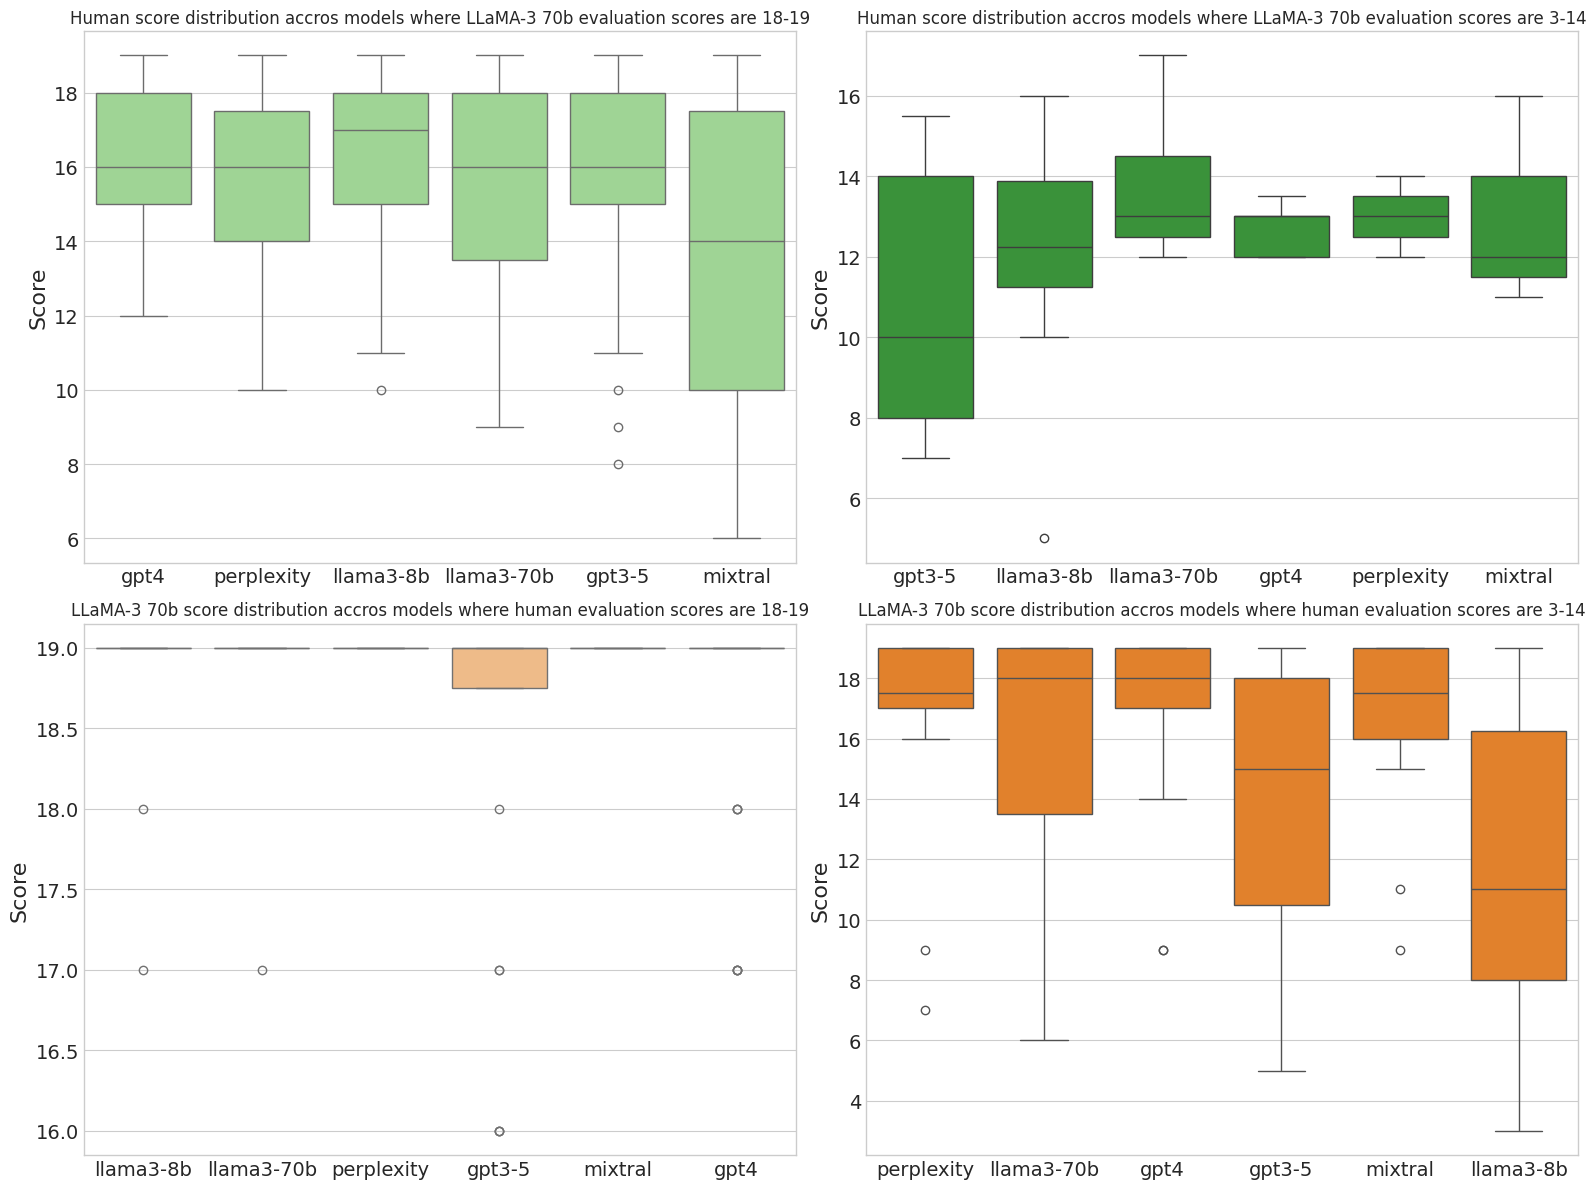

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
datasets = read_eval_datasets()
set1_colors = plt.get_cmap('tab20').colors

# Merge datasets on common fields (only keeping common rows)
common_columns = ["object1", "object2", "model", 'scenario']
merged_df = pd.merge(datasets['human'], datasets['llama70b'], on=common_columns, suffixes=("_human", "_llama"))

# Define score filtering criteria using the correct dataset
score_filters = {
    "GPT-4 Score 18-19": merged_df.loc[merged_df["score_llama"].between(18, 19)],
    "GPT-4 Score 3-14": merged_df.loc[merged_df["score_llama"].between(3, 14)],
    "Human Score 18-19": merged_df.loc[merged_df["score_human"].between(18, 19)],
    "Human Score 3-14": merged_df.loc[merged_df["score_human"].between(3, 14)]
}

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define unique conditions and corresponding subplot titles


titles = {
     "GPT-4 Score 18-19": "Human score distribution accros models where LLaMA-3 70b evaluation scores are 18-19",
    "GPT-4 Score 3-14": "Human score distribution accros models where LLaMA-3 70b evaluation scores are 3-14",
    "Human Score 18-19": "LLaMA-3 70b score distribution accros models where human evaluation scores are 18-19",
    "Human Score 3-14": "LLaMA-3 70b score distribution accros models where human evaluation scores are 3-14"
}

c=5
# Plot each filtered condition in a separate subplot
for ax, (condition, subset) in zip(axes.flatten(), score_filters.items()):
    if not subset.empty:  # Ensure data exists before plotting
        sns.boxplot(x="model", y="score_llama" if "Human" in condition else "score_human", 
                    data=subset, ax=ax, color=set1_colors[c])
        ax.set_title(titles[condition])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=14)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)
        ax.set_ylabel('Score', fontsize=16)
        ax.set_xlabel('')
        
    else:
        ax.set_title(f"No Data for {condition}")  # Handle empty cases
    c-=1
    

# Adjust layout and show the figure
plt.tight_layout()
plt.savefig("distributions.pdf")


In [8]:


subplots = ['llama70b', 'human']
title = "Average scores across differenr scenarios"

# models = ['llama3-70b', 'perplexity']
# titles = ['LLaMA3-70B', 'Perplexity.ai']

xaxis_groups = ['LlaMA-3 70b', 'Human']

labels = {'s1': 'Scenario-1', 
           's2':'Scenario-2', 
           's3':'Scenario-3', 
           's4':'Scenario-4'}



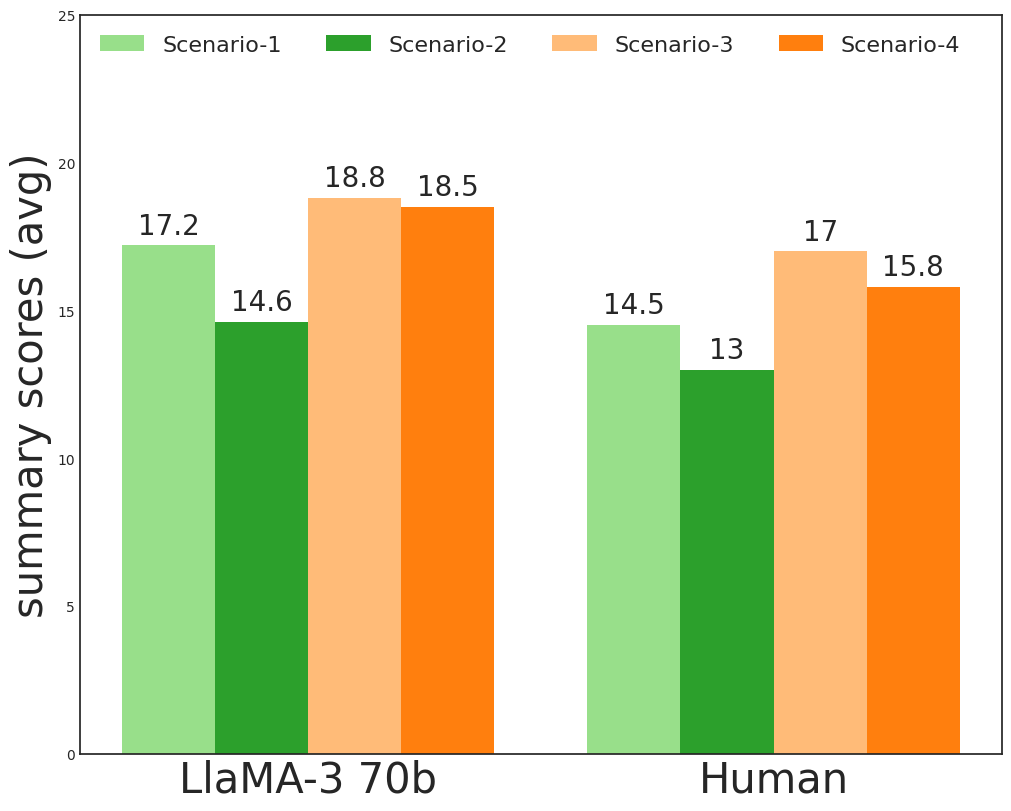

In [18]:
import matplotlib.pyplot as plt
import numpy as np
plot_styles = plt.style.available
style = 27
plt.style.use(plot_styles[style])
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-white')
set1_colors = plt.get_cmap('tab20').colors

x = np.arange(len(xaxis_groups))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, axes = plt.subplots(nrows=1, ncols=1,  figsize=(10,8), layout='constrained')
# fig, axes = plt.subplots(nrows=2, ncols=1, layout='constrained', figsize=(6,8))

# ax.bar()
# for i,model in enumerate(models):
ax = axes
means_scores = graph_data
multiplier = 0
c = 5
for lbl, data in means_scores.items():
    # print(lbl, data)
    offset = width * multiplier
    rects = ax.bar(x + offset, data, width, 
                   label=labels[lbl], 
                   color=set1_colors[c]
                  )
    ax.bar_label(rects, padding=4, fontsize=20)
    c-=1


# if i == 0:
    ax.set_ylabel('summary scores (avg)', fontsize=30)

    #ax.set_title(title)

    ax.legend(loc='upper left', ncols=4, fontsize=16)
    ax.set_ylim(0, 25)
    ax.set_xticks(x + width+ 0.1, xaxis_groups, fontsize=30) 

    multiplier += 1

# axes[1].set_xticks(x + width, criteria_groups) 
plt.savefig(f'avg_scenarios-{style}')

plt.savefig("scenarios.pdf", dpi=100)


###### Scenarios -- grouped criteria

### group scenarios

In [19]:
structure_cols = [f"C{i}" for i in [1,2,3,4,5,6,7]]
relevance_cols = [f"C{i}" for i in [8,9,10]]
quality_cols =  [f"C{i}" for i in [11,12,13,14,15]]

COLUMNS4 =  ['model', 'scenario', 'structure', 'relevance', 'quality']


def group_criteria(input_df, COLUMNS=COLUMNS4):
    df = pd.DataFrame(columns = COLUMNS)
    for col in COLUMNS[:-3]:
        
        df[col] = input_df[col]
        df[col] = input_df[col]#.apply(lambda x: int(x) if x in "1,2,3,4" else x)
    
    df['structure'] = input_df[structure_cols].sum(axis=1)
    df['relevance'] = input_df[relevance_cols].sum(axis=1)
    df['quality'] = input_df[quality_cols].sum(axis=1)
    
    return df 

In [20]:
      
datasets = read_eval_datasets()


COLUMNS3 = [ 'model', 'scenario',  *[f"C{i}" for i in range(1,16)]] 
COLUMNS4 =  ['scenario', 'structure', 'relevance', 'quality']

for scorer, df in datasets.items():
    

    datasets[scorer] = group_criteria(datasets[scorer]).round(1)   

    datasets[scorer] = datasets[scorer][COLUMNS4].groupby(['scenario']).mean().reset_index([ 'scenario' ]).round(1)

datasets['llama70b']


,scenario,structure,relevance,quality
0,1,6.2,4.8,6.1
1,2,5.1,3.9,5.6
2,3,6.9,5.0,6.9
3,4,6.9,4.8,6.8
4,m,1.0,1.8,3.6
5,n,6.7,4.6,6.6
6,o,0.8,1.3,3.9


In [21]:
models = ['llama70b', 'human']
# models = ['GPT-0-shot', 'GPT-2-shot', 'Human']

graph_data = {}
criteria_groups = ['structure', 'relevance', 'quality']


graph_data = {}
for model in models:
    print(model)
#     mdf = dfg.loc[dfg['model']==model].copy()
    mdf = datasets[model]
    graph_data[model]={'s1': mdf.loc[mdf['scenario']==1][criteria_groups].values.tolist()[0],
                      's2': mdf.loc[mdf['scenario']==2][criteria_groups].values.tolist()[0],
                        's3': mdf.loc[mdf['scenario']==3][criteria_groups].values.tolist()[0],
                        's4': mdf.loc[mdf['scenario']==4][criteria_groups].values.tolist()[0]
                        }

    
graph_data  



llama70b
human


{'llama70b': {'s1': [6.2, 4.8, 6.1],
  's2': [5.1, 3.9, 5.6],
  's3': [6.9, 5.0, 6.9],
  's4': [6.9, 4.8, 6.8]},
 'human': {'s1': [5.2, 3.6, 5.7],
  's2': [4.1, 3.5, 5.4],
  's3': [6.5, 4.2, 6.4],
  's4': [6.3, 3.2, 6.2]}}

In [22]:
# models = ['llama3-70b', 'perplexity']

# graph_data = {}
# criteria_groups = ['structure', 'relevance', 'quality']


# dfg = dfg1.copy()
# graph_data = {}
# for model in models:
#     mdf = dfg.loc[dfg['model']==model].copy()
#     graph_data[model]={'s1': mdf.loc[mdf['scenario']==1][criteria_groups].values.tolist()[0],
#                       's2': mdf.loc[mdf['scenario']==2][criteria_groups].values.tolist()[0],
#                         's3': mdf.loc[mdf['scenario']==3][criteria_groups].values.tolist()[0],
#                         's4': mdf.loc[mdf['scenario']==4][criteria_groups].values.tolist()[0]
#                         }

    
# graph_data  



s1 [6.2, 4.8, 6.1]
s2 [5.1, 3.9, 5.6]
s3 [6.9, 5.0, 6.9]
s4 [6.9, 4.8, 6.8]
s1 [5.2, 3.6, 5.7]
s2 [4.1, 3.5, 5.4]
s3 [6.5, 4.2, 6.4]
s4 [6.3, 3.2, 6.2]


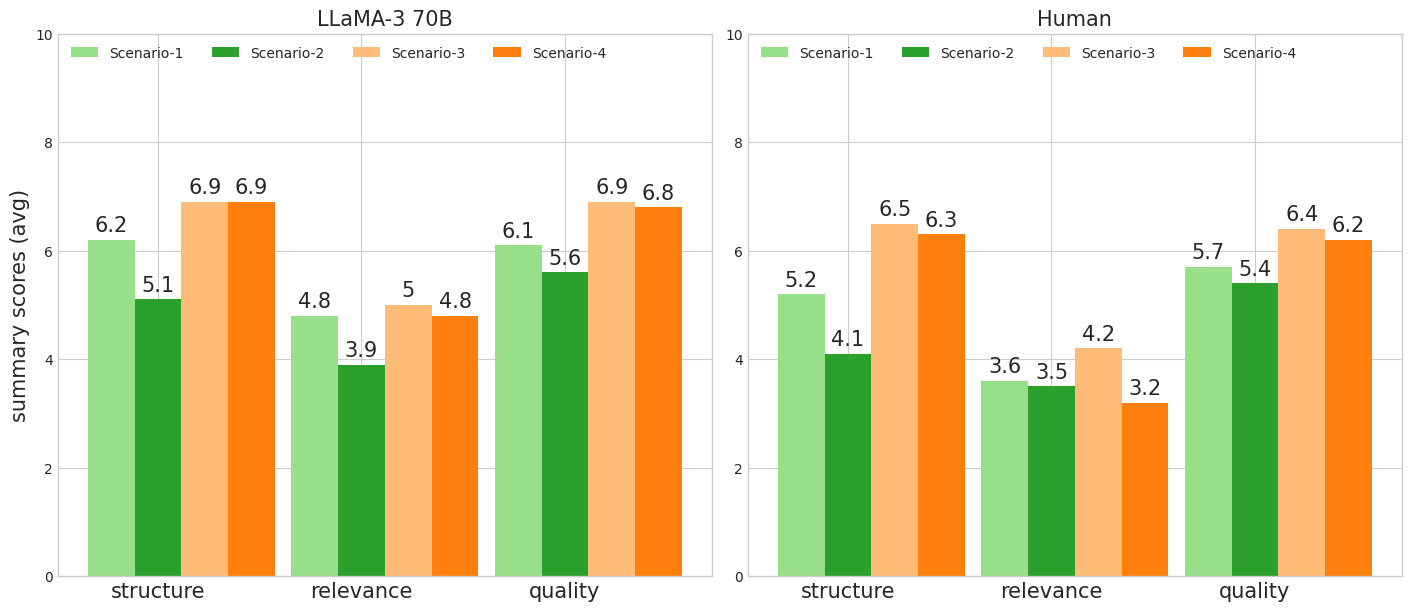

In [35]:
import matplotlib.pyplot as plt
import numpy as np

style = 27
plt.style.use(plt.style.available[style])
# plt.style.use('ggplot')
# plt.style.use('seaborn-v0_8-white')
set1_colors = plt.get_cmap('tab20').colors

models = ['llama70b', 'human']
titles = ['LLaMA-3 70B', 'Human']

# models = ['llama3-70b', 'perplexity']
# titles = ['LLaMA3-70B', 'Perplexity.ai']

xaxis_groups = ['structure', 'relevance', 'quality']
labels = {'s1': 'Scenario-1', 
           's2':'Scenario-2', 
           's3':'Scenario-3', 
           's4':'Scenario-4'}


means_scores = graph_data[models[0]]

x = np.arange(len(criteria_groups))  # the label locations
width = 0.23  # the width of the bars
multiplier = 0

fig, axes = plt.subplots(nrows=1, ncols=2,  figsize=(14,6), layout='constrained')
# fig, axes = plt.subplots(nrows=2, ncols=1, layout='constrained', figsize=(6,8))

# ax.bar()
for i,model in enumerate(models):
    ax = axes[i]
    co=5
    means_scores = means_scores = graph_data[model]
    multiplier = 0
    for lbl, data in means_scores.items():
        print(lbl, data)
        offset = width * multiplier
        rects = ax.bar(x + offset, data, width, 
                       label=labels[lbl], color=set1_colors[co]
                      )
        ax.bar_label(rects, padding=3, fontsize=15)
        co-=1
    
        
        if i == 0:
            ax.set_ylabel('summary scores (avg)', fontsize=15)
            
        ax.set_title(titles[i], fontsize=15)
        
        ax.legend(loc='upper left', ncols=4, fontsize=10)
        ax.set_ylim(0, 10)
        ax.set_xticks(x + width, xaxis_groups, fontsize=15) 
    
        multiplier += 1

# plt.rcParams.update({
#     'axes.titlesize': 16,  # Title font size
#     'axes.labelsize': 16,  # Axis label font size
#     'xtick.labelsize': 16,  # X-axis tick label font size
#     'ytick.labelsize': 16,  # Y-axis tick label font size
#     'legend.fontsize': 16,  # Legend font size
#     'font.size': 12  # General font size
# })

# axes[1].set_xticks(x + width, criteria_groups) 
plt.savefig(f'average_criteria-{style}.pdf', dpi=100)

plt.show()

## GPT 4 vs Human 
on one model 


In [16]:
        

datasets = read_eval_datasets()

# COLUMNS = [ 'aspect', 'model', 'scenario', 'score'] 
COLUMNS = [ 'aspect',  'score'] 

for scorer, _ in datasets.items():
#     print(scorer)
    datasets[scorer] = datasets[scorer][COLUMNS]
    datasets[scorer] = datasets[scorer].fillna(value={'aspect':''})
    datasets[scorer]['aspect'] =  datasets[scorer]['aspect'].apply(lambda x: 'yes' if x!='' else 'no')

#     datasets[scorer] = datasets[scorer].groupby(['aspect','model', 'scenario']).mean().reset_index(['aspect', 'model' , 'scenario' ])
    datasets[scorer] = datasets[scorer].groupby(['aspect']).mean().reset_index(['aspect' ])


df = pd.DataFrame(columns=COLUMNS)
df = datasets["zero"][COLUMNS[:-1]]
# df = df.sort_values(by=["model", "scenario"])

for scorer, _ in datasets.items():
    
    df[f'{scorer}'] = datasets[scorer]["score"]
#     df[f'{scorer}'] = datasets[scorer].sort_values(by=["model", "scenario"])["score"]

# datasets_avg['few']#.sort_values(by="score", ascending=False)
df


zero
few
human


,aspect,zero,few,human
0,no,17.963713,16.939649,15.327434
1,yes,17.590106,16.780919,13.911348


In [44]:
print(df.to_latex())

\begin{tabular}{llrrr}
\toprule
 & aspect & zero & few & human \\
\midrule
0 & no & 17.963713 & 16.870296 & 15.327434 \\
1 & yes & 17.590106 & 16.692213 & 13.911348 \\
\bottomrule
\end{tabular}



In [ ]:
COLUMNS4 =  ['model', 'scenario', 'aspect' 'structure', 'relevance', 'quality']

datasets = read_eval_datasets()
for d,_ in datasets.items():
    datasets[d]

In [21]:
datasets = read_eval_datasets()


df1 = datasets['human'][COLUMNS3].copy()
dfg1 = group_criteria(df1).round(1)   
dfg1


df2 = datasets['zero'][COLUMNS3].copy()
dfg2 = group_criteria(df2).round(1)   
dfg2

zero
few
human


,scenario,structure,relevance,quality,model
0,3,7.0,5.0,7.0,perplexity
1,3,7.0,4.0,7.0,perplexity
2,3,7.0,5.0,7.0,perplexity
3,3,6.0,5.0,7.0,perplexity
4,3,7.0,5.0,7.0,perplexity
...,...,...,...,...,...
2153,summaries,7.0,5.0,7.0,human
2154,summaries,7.0,5.0,7.0,human
2155,summaries,7.0,4.0,5.0,human
2156,summaries,7.0,5.0,7.0,human


In [22]:
# models = ['llama3-70b', 'perplexity']
models = ['perplexity']

graph_data1 = {}
criteria_groups = ['structure', 'relevance', 'quality']


dfg = dfg1.copy()
graph_data = {}
for model in models:
    mdf = dfg.loc[dfg['model']==model].copy()
    graph_data1[model]={'s1': mdf.loc[mdf['scenario']==1][criteria_groups].values.tolist()[0],
                      's2': mdf.loc[mdf['scenario']==2][criteria_groups].values.tolist()[0],
                        's3': mdf.loc[mdf['scenario']==3][criteria_groups].values.tolist()[0],
                        's4': mdf.loc[mdf['scenario']==4][criteria_groups].values.tolist()[0]
                        }

    


dfg = dfg2.copy()
graph_data2 = {}
for model in models:
    mdf = dfg.loc[dfg['model']==model].copy()
    graph_data2[model]={'s1': mdf.loc[mdf['scenario']==1][criteria_groups].values.tolist()[0],
                      's2': mdf.loc[mdf['scenario']==2][criteria_groups].values.tolist()[0],
                        's3': mdf.loc[mdf['scenario']==3][criteria_groups].values.tolist()[0],
                        's4': mdf.loc[mdf['scenario']==4][criteria_groups].values.tolist()[0]
                        }
graph_data2

{'perplexity': {'s1': [6.0, 5.0, 6.0],
  's2': [5.0, 4.0, 6.0],
  's3': [7.0, 5.0, 7.0],
  's4': [7.0, 5.0, 7.0]}}

In [23]:
model = 'perplexity'
graph_data = {'s1': {'human':graph_data1[model]['s1'], 'gpt4':graph_data2[models[0]]['s1']},
             's2': {'human':graph_data1[model]['s2'],  'gpt4':graph_data2[models[0]]['s2']},
             's3': {'human':graph_data1[model]['s3'],  'gpt4':graph_data2[models[0]]['s3']},
             's4': {'human':graph_data1[model]['s4'],  'gpt4':graph_data2[models[0]]['s4']}
             }

graph_data

{'s1': {'human': [4.5, 1.5, 5.5], 'gpt4': [6.0, 5.0, 6.0]},
 's2': {'human': [3.0, 4.0, 6.0], 'gpt4': [5.0, 4.0, 6.0]},
 's3': {'human': [6.5, 5.0, 5.5], 'gpt4': [7.0, 5.0, 7.0]},
 's4': {'human': [6.5, 4.5, 7.0], 'gpt4': [7.0, 5.0, 7.0]}}

In [ ]:
import matplotlib.pyplot as plt
plt.style.available

[0 1 2]
human [4.5, 1.5, 5.5]
gpt4 [6.0, 5.0, 6.0]
human [3.0, 4.0, 6.0]
gpt4 [5.0, 4.0, 6.0]
human [6.5, 5.0, 5.5]
gpt4 [7.0, 5.0, 7.0]
human [6.5, 4.5, 7.0]
gpt4 [7.0, 5.0, 7.0]


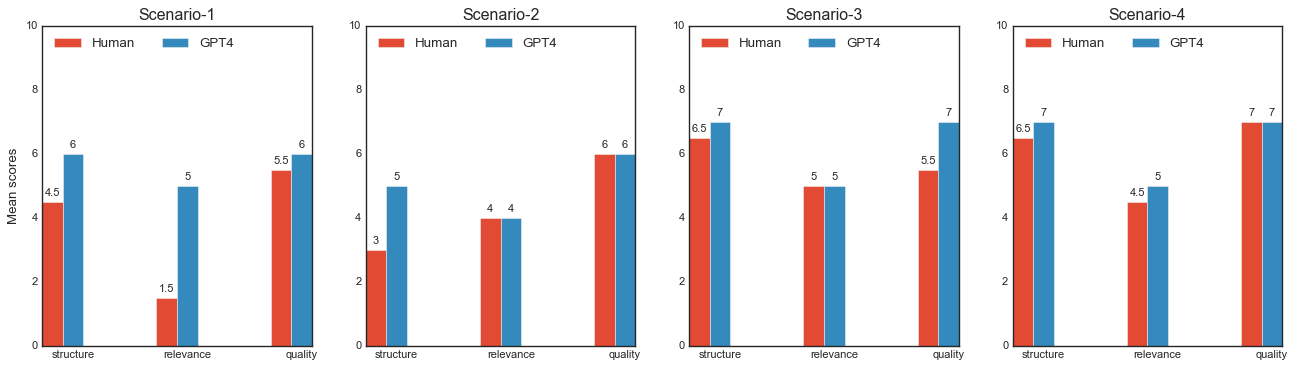

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-white')


Title = ['LLaMA3-70B', 'Perplexity.ai']
models = ['llama3-70b', 'perplexity']

axis_labels = ['structure', 'relevance', 'quality']

titles = {'s1': 'Scenario-1', 
           's2':'Scenario-2', 
           's3':'Scenario-3', 
           's4':'Scenario-4'}

labels = {'human': "Human",
         "gpt4": "GPT4"}

x = np.arange(len(axis_labels))  # the label locations
print(x)
width = 0.18  # the width of the bars
multiplier = 0

fig, axes = plt.subplots(nrows=1, ncols=4,  figsize=(20,5))
# fig, axes = plt.subplots(nrows=2, ncols=1, layout='constrained', figsize=(6,8))

# ax.bar()
for i, subplot in enumerate(titles.keys()):
    ax = axes[i]
    means_scores = means_scores = graph_data[subplot]
    multiplier = 0
    for lbl, data in means_scores.items():
        print(lbl, data)
        offset = width * multiplier
        rects = ax.bar(x + offset, data, width, 
                       label=labels[lbl],
                      )
        ax.bar_label(rects, padding=3)
    
        
        if i == 0:
            ax.set_ylabel('Mean scores')
            
        ax.set_title(titles[subplot])
        
        ax.legend(loc='upper left', ncols=2)
        ax.set_ylim(0, 10)
        ax.set_xticks(x + width, axis_labels) 
    
        multiplier += 1

# axes[1].set_xticks(x + width, criteria_groups) 
plt.show()

## Find common example to compare eval of gpt and human

In [ ]:
datasets = read_eval_datasets()
score_columns = criteria_columns +["score"]

In [ ]:
for d in datasets.keys():
    datasets[d]["pair"] = datasets[d]["object1"] +" vs. "+ datasets[d]["object2"]
    datasets[d]["score"] = datasets[d].apply(add_scores, axis=1)
    datasets[d] = datasets[d].loc[datasets[d]["scenario"]==1].copy()


In [ ]:
dfh = datasets["human"]
dfg = datasets["zero"]
dfg2 = datasets["few"]

# pairs = dfh["pair"].unique().tolist()
# pairs

In [ ]:
# dfh.loc[dfh["score"]<16]
dfh.loc[dfh["object1"]=="dell"]

In [ ]:
dfg.loc[(dfg["score"]>15) & (dfg["model"]=="mixtral")][""]

In [ ]:
p = "ds vs. ps3"
p = "dell vs. ibm"

m = "mixtral"

In [ ]:
print(dfg.loc[(dfg["pair"]==p) & (dfg["model"]==m)]["comparison"].iloc[0])

In [ ]:
dfh.loc[(dfh["pair"]==p) & (dfh["model"]==m)][score_columns]

In [ ]:
dfg.loc[(dfg["pair"]==p) & (dfg["model"]==m)][score_columns]

In [ ]:
dfg2.loc[(dfg2["pair"]==p) & (dfg2["model"]==m)][score_columns]